
# Python local small-scale test: 3D Heisenberg + DMI

This notebook replaces the Julia local notebook. It uses only Python/NumPy/Matplotlib and is meant as a **small-scale sanity check** before running the production C++/Euler workflow.

It performs:

- 3D Heisenberg + Dzyaloshinskii–Moriya Metropolis simulation
- periodic boundary conditions
- energy, magnetization, heat capacity, susceptibility
- helical order $ \max_{q\neq 0} S(q) $
- small temperature scan
- colored 2D spin slice without arrows

For final production, use the C++ executable and Euler scripts.


In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from pathlib import Path

FIG_DIR = Path("../figures/python_local")
FIG_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR = Path("../results/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Python local notebook ready.")


Python local notebook ready.



## Model

We simulate

$$
H =
-J\sum_{\mathbf r,\mu}\mathbf S_{\mathbf r}\cdot \mathbf S_{\mathbf r+\hat\mu}
-D\sum_{\mathbf r,\mu}\hat\mu\cdot
(\mathbf S_{\mathbf r}\times \mathbf S_{\mathbf r+\hat\mu})
-\mathbf B\cdot\sum_{\mathbf r}\mathbf S_{\mathbf r}.
$$

For local testing we use \(J=1\), \(D=1\), \(B=0\). Then

$$
q_0 = \arctan(D/J)=\pi/4,
$$

so the helical pitch is \(8\) lattice spacings.


In [13]:

def random_unit_vector(rng):
    z = 2.0 * rng.random() - 1.0
    phi = 2.0 * np.pi * rng.random()
    r = np.sqrt(max(0.0, 1.0 - z*z))
    return np.array([r*np.cos(phi), r*np.sin(phi), z], dtype=np.float64)

def normalize(v):
    n = np.linalg.norm(v)
    if n == 0:
        return np.array([1.0, 0.0, 0.0], dtype=np.float64)
    return v / n

def helical_z_initial(L, J=1.0, D=1.0):
    q0 = np.arctan(D / J)
    n = max(1, int(round(q0 * L / (2*np.pi))))
    q = 2*np.pi*n/L
    spins = np.zeros((L, L, L, 3), dtype=np.float64)
    for z in range(L):
        angle = q*z
        spins[:, :, z, 0] = np.cos(angle)
        spins[:, :, z, 1] = np.sin(angle)
        spins[:, :, z, 2] = 0.0
    return spins, q, n

def total_energy(spins, J=1.0, D=1.0, B=np.zeros(3)):
    # Count positive bonds once.
    E = 0.0
    dirs = [
        (0, np.array([1.0, 0.0, 0.0])),
        (1, np.array([0.0, 1.0, 0.0])),
        (2, np.array([0.0, 0.0, 1.0])),
    ]
    for axis, ehat in dirs:
        nbr = np.roll(spins, shift=-1, axis=axis)
        dot = np.sum(spins * nbr, axis=-1)
        cross = np.cross(spins, nbr)
        dm = np.tensordot(cross, ehat, axes=([-1],[0]))
        E += np.sum(-J * dot - D * dm)
    if np.linalg.norm(B) > 0:
        E += -np.tensordot(spins, B, axes=([-1],[0])).sum()
    return float(E)

def local_energy(spins, x, y, z, s, J=1.0, D=1.0, B=np.zeros(3)):
    L = spins.shape[0]
    E = -np.dot(B, s)
    neigh = [
        ((x+1)%L, y, z, np.array([ 1.0, 0.0, 0.0])),
        ((x-1)%L, y, z, np.array([-1.0, 0.0, 0.0])),
        (x, (y+1)%L, z, np.array([0.0,  1.0, 0.0])),
        (x, (y-1)%L, z, np.array([0.0, -1.0, 0.0])),
        (x, y, (z+1)%L, np.array([0.0, 0.0,  1.0])),
        (x, y, (z-1)%L, np.array([0.0, 0.0, -1.0])),
    ]
    for xp, yp, zp, ehat in neigh:
        sj = spins[xp, yp, zp]
        E += -J * np.dot(s, sj)
        E += -D * np.dot(ehat, np.cross(s, sj))
    return float(E)

def metropolis_sweep(spins, T, J=1.0, D=1.0, proposal_width=0.7, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    L = spins.shape[0]
    accepted = 0
    for _ in range(L**3):
        x = rng.integers(L)
        y = rng.integers(L)
        z = rng.integers(L)
        old = spins[x, y, z].copy()
        new = normalize(old + proposal_width * random_unit_vector(rng))
        E_old = local_energy(spins, x, y, z, old, J=J, D=D)
        E_new = local_energy(spins, x, y, z, new, J=J, D=D)
        dE = E_new - E_old
        if dE <= 0 or rng.random() < np.exp(-dE / T):
            spins[x, y, z] = new
            accepted += 1
    return accepted / (L**3)

def magnetization_density(spins):
    m = spins.mean(axis=(0,1,2))
    return float(np.linalg.norm(m))

def structure_factor_axis(spins, axis, n):
    L = spins.shape[0]
    q = 2*np.pi*n/L
    coords = np.arange(L)
    phase = np.exp(1j*q*coords)
    if axis == 0:
        amp = np.tensordot(phase, spins, axes=(0,0))
    elif axis == 1:
        amp = np.tensordot(phase, spins, axes=(0,1))
    else:
        amp = np.tensordot(phase, spins, axes=(0,2))
    amp_vec = amp.reshape(-1, 3).sum(axis=0)
    N = L**3
    return float(np.sum(np.abs(amp_vec)**2) / (N*N))

def helical_order(spins):
    L = spins.shape[0]
    best = -1.0
    best_axis = None
    best_n = None
    best_q = None
    for axis in range(3):
        for n in range(1, L):
            val = structure_factor_axis(spins, axis, n)
            if val > best:
                best = val
                best_axis = axis
                best_n = n
                best_q = 2*np.pi*n/L
    return best, best_q, best_axis, best_n


In [14]:

def run_single(
    L=8, T=1.0, J=1.0, D=1.0, seed=1,
    thermalization_sweeps=80,
    measurement_samples=100,
    sweeps_between_measurements=2,
    proposal_width=0.7,
    return_spins=False,
):
    rng = np.random.default_rng(seed + 1000*L + int(100*T))
    spins, q_init, n_init = helical_z_initial(L, J=J, D=D)

    for _ in range(thermalization_sweeps):
        metropolis_sweep(spins, T, J=J, D=D, proposal_width=proposal_width, rng=rng)

    E_data = []
    M_data = []
    H_data = []
    acc_data = []

    for _ in range(measurement_samples):
        acc = 0.0
        for _ in range(sweeps_between_measurements):
            acc += metropolis_sweep(spins, T, J=J, D=D, proposal_width=proposal_width, rng=rng)
        acc_data.append(acc / sweeps_between_measurements)

        e = total_energy(spins, J=J, D=D) / (L**3)
        m = magnetization_density(spins)
        h, q, axis, n = helical_order(spins)

        E_data.append(e)
        M_data.append(m)
        H_data.append(h)

    E_data = np.array(E_data)
    M_data = np.array(M_data)
    H_data = np.array(H_data)
    h_final, q_final, axis_final, n_final = helical_order(spins)

    row = {
        "L": L,
        "T": T,
        "J": J,
        "D": D,
        "seed": seed,
        "E_density_mean": E_data.mean(),
        "E_density_stderr": E_data.std(ddof=1) / np.sqrt(len(E_data)),
        "M_abs_mean": M_data.mean(),
        "M_abs_stderr": M_data.std(ddof=1) / np.sqrt(len(M_data)),
        "Cv_per_spin": L**3 * E_data.var(ddof=1) / (T*T),
        "chi_abs": L**3 * M_data.var(ddof=1) / T,
        "helical_order_mean": H_data.mean(),
        "helical_order_stderr": H_data.std(ddof=1) / np.sqrt(len(H_data)),
        "helical_susc_like": L**3 * H_data.var(ddof=1) / T,
        "acceptance_rate": np.mean(acc_data),
        "q_peak_final": q_final,
        "axis_peak_final": axis_final,
        "n_peak_final": n_final,
        "q_init": q_init,
        "n_init": n_init,
    }

    if return_spins:
        return row, spins.copy()
    return row


## Single sanity check

In [15]:

row, spins_low_debug = run_single(
    L=8, T=0.8, J=1.0, D=1.0, seed=1,
    thermalization_sweeps=50,
    measurement_samples=50,
    sweeps_between_measurements=1,
    proposal_width=0.7,
    return_spins=True,
)

row


{'L': 8,
 'T': 0.8,
 'J': 1.0,
 'D': 1.0,
 'seed': 1,
 'E_density_mean': np.float64(-2.560478674068185),
 'E_density_stderr': np.float64(0.003457212747689843),
 'M_abs_mean': np.float64(0.07495618595578338),
 'M_abs_stderr': np.float64(0.002863035057588209),
 'Cv_per_spin': np.float64(0.4780927993115662),
 'chi_abs': np.float64(0.2623030317113318),
 'helical_order_mean': np.float64(0.3139214720320806),
 'helical_order_stderr': np.float64(0.0011906509994599665),
 'helical_susc_like': np.float64(0.04536479368048055),
 'acceptance_rate': np.float64(0.4968359375),
 'q_peak_final': 0.7853981633974483,
 'axis_peak_final': 2,
 'n_peak_final': 1,
 'q_init': 0.7853981633974483,
 'n_init': 1}

## Small temperature scan

In [16]:

# Keep this intentionally small. Production runs use C++/Euler.
Ls = [8]
temperatures = [0.8, 1.2, 1.6, 2.0]
seeds = [1, 2]

rows = []
for L in Ls:
    for T in temperatures:
        for seed in seeds:
            print(f"Running L={L}, T={T}, seed={seed}")
            rows.append(run_single(
                L=L, T=T, J=1.0, D=1.0, seed=seed,
                thermalization_sweeps=60,
                measurement_samples=80,
                sweeps_between_measurements=2,
                proposal_width=0.7,
            ))

df = pd.DataFrame(rows)
df.to_csv(OUT_DIR / "python_local_scan.csv", index=False)
df.head()


Running L=8, T=0.8, seed=1
Running L=8, T=0.8, seed=2


KeyboardInterrupt: 

In [ ]:

summary = (
    df.groupby(["L", "T"])
      .agg(
          E=("E_density_mean", "mean"),
          E_err=("E_density_mean", "std"),
          M=("M_abs_mean", "mean"),
          M_err=("M_abs_mean", "std"),
          Cv=("Cv_per_spin", "mean"),
          chi=("chi_abs", "mean"),
          H=("helical_order_mean", "mean"),
          H_err=("helical_order_mean", "std"),
          Hfluc=("helical_susc_like", "mean"),
          acc=("acceptance_rate", "mean"),
          qpeak=("q_peak_final", "mean"),
      )
      .reset_index()
)
summary.to_csv(OUT_DIR / "python_local_scan_summary.csv", index=False)
summary


,L,T,E,E_err,M,M_err,Cv,chi,H,H_err,Hfluc,acc,qpeak
0,8,0.8,-2.545881,0.013404,0.054638,0.009254,1.116020,0.298745,0.294662,0.008099,0.080708,0.495801,3.141593
1,8,1.2,-1.981744,0.039852,0.064444,0.010482,2.063821,0.252734,0.157914,0.019191,0.300232,0.617767,3.141593
2,8,1.6,-1.383813,0.007039,0.102091,0.005254,1.143399,0.251077,0.038049,0.007979,0.100045,0.718903,3.141593
3,8,2.0,-1.010525,0.056413,0.062864,0.023874,0.475682,0.170297,0.014054,0.003012,0.017542,0.783783,1.178097


## Local plots

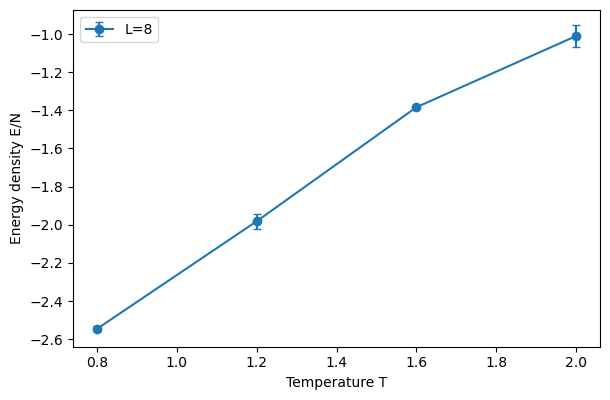

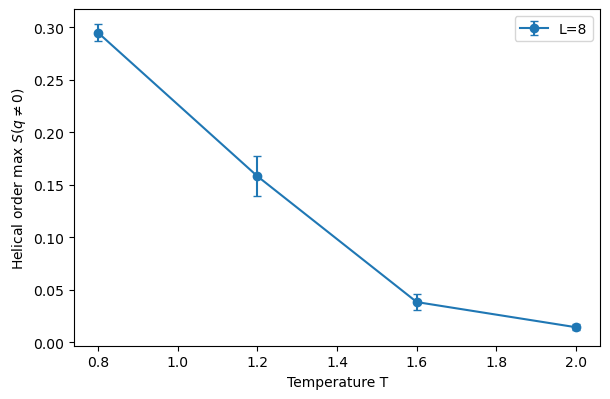

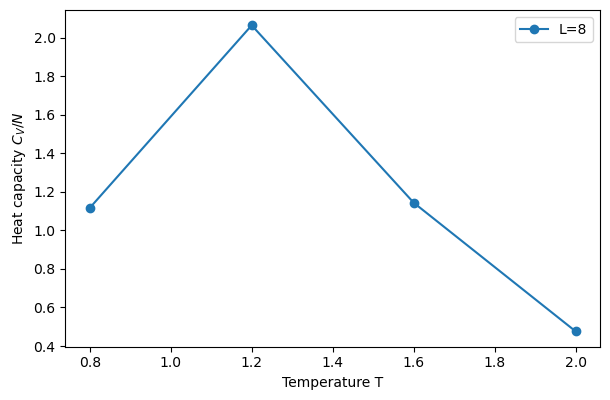

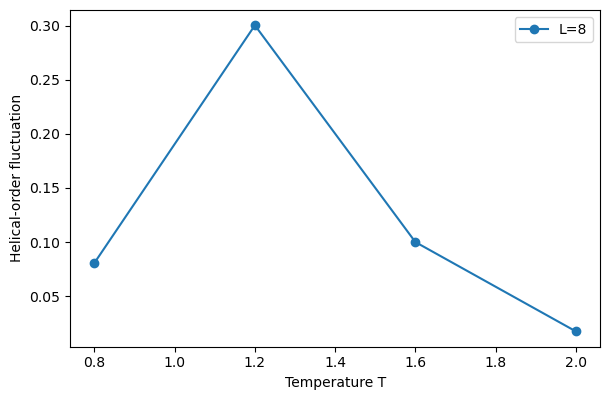

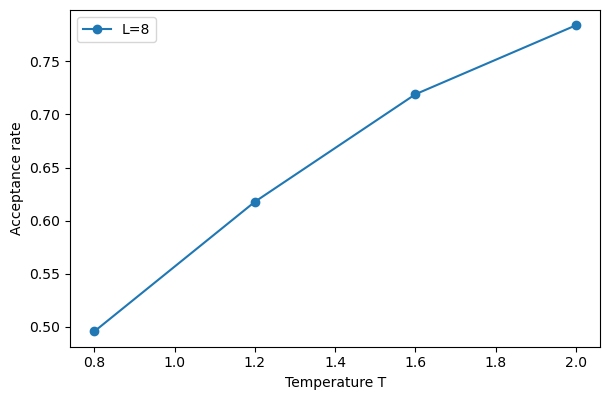

In [ ]:

def plot_vs_T(y, ylabel, filename, yerr=None):
    fig, ax = plt.subplots(figsize=(6.2, 4.1))
    for L, d in summary.groupby("L"):
        d = d.sort_values("T")
        err = d[yerr] if yerr and yerr in d.columns else None
        ax.errorbar(d["T"], d[y], yerr=err, marker="o", capsize=3, label=f"L={L}")
    ax.set_xlabel("Temperature T")
    ax.set_ylabel(ylabel)
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=200)
    fig.savefig(FIG_DIR / filename.replace(".png", ".pdf"))
    plt.show()

plot_vs_T("E", "Energy density E/N", "python_energy_density.png", "E_err")
plot_vs_T("H", r"Helical order max $S(q\neq0)$", "python_helical_order.png", "H_err")
plot_vs_T("Cv", r"Heat capacity $C_V/N$", "python_heat_capacity.png")
plot_vs_T("Hfluc", "Helical-order fluctuation", "python_helical_fluctuation.png")
plot_vs_T("acc", "Acceptance rate", "python_acceptance.png")



## Colored 2D slice visualization without arrows

This is the requested visualization.

- Hue/color: in-plane spin angle \(\theta=\arctan(S_y,S_x)\)
- Brightness: out-of-plane component \(S_z\)

This is much denser and cleaner than arrows for a 2D slice.


In [ ]:

def spin_to_rgb(spins):
    sx = spins[..., 0]
    sy = spins[..., 1]
    sz = spins[..., 2]
    phi = np.arctan2(sy, sx)
    hue = (phi / (2*np.pi)) % 1.0
    sat = np.full_like(hue, 0.95)
    val = 0.55 + 0.45*(sz + 1)/2
    hsv = np.stack([hue, sat, val], axis=-1)
    return hsv_to_rgb(hsv)

def colored_slice_image(spins, plane="xz", index=None):
    L = spins.shape[0]
    if index is None:
        index = L // 2
    if plane == "xz":
        sl = spins[:, index, :, :]
        xlabel, ylabel = "x", "z"
    elif plane == "xy":
        sl = spins[:, :, index, :]
        xlabel, ylabel = "x", "y"
    elif plane == "yz":
        sl = spins[index, :, :, :]
        xlabel, ylabel = "y", "z"
    else:
        raise ValueError("plane must be xy, xz, or yz")
    img = spin_to_rgb(sl)
    # transpose image so horizontal axis is first coordinate and vertical is second
    img = np.swapaxes(img, 0, 1)
    img = img[::-1, :, :]
    return img, xlabel, ylabel

def plot_colored_slice(spins, title, filename, plane="xz", index=None):
    img, xlabel, ylabel = colored_slice_image(spins, plane=plane, index=index)
    fig, ax = plt.subplots(figsize=(5.2, 5.0))
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=250)
    fig.savefig(FIG_DIR / filename.replace(".png", ".pdf"))
    plt.show()


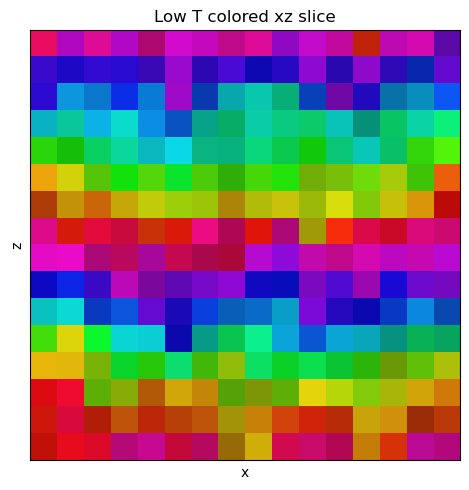

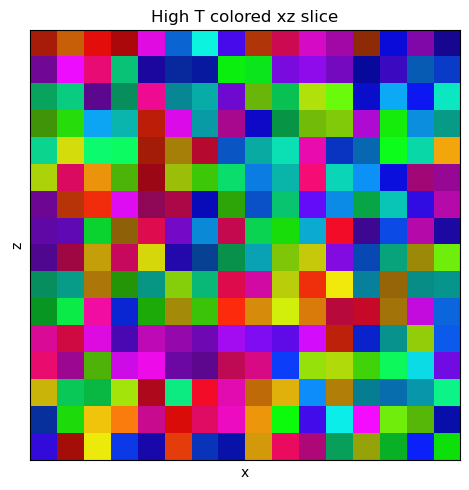

({'L': 16,
  'T': 0.6,
  'J': 1.0,
  'D': 1.0,
  'seed': 10,
  'E_density_mean': np.float64(-2.7789258696249943),
  'E_density_stderr': np.float64(0.0009484617192418576),
  'M_abs_mean': np.float64(0.01700299859537977),
  'M_abs_stderr': np.float64(0.0012392717328405132),
  'Cv_per_spin': np.float64(0.4094086862471261),
  'chi_abs': np.float64(0.4193742650893732),
  'helical_order_mean': np.float64(0.3268958198796404),
  'helical_order_stderr': np.float64(0.000705281829335109),
  'helical_susc_like': np.float64(0.1358294927469986),
  'acceptance_rate': np.float64(0.4194793701171875),
  'q_peak_final': 0.7853981633974483,
  'axis_peak_final': 2,
  'n_peak_final': 2,
  'q_init': 0.7853981633974483,
  'n_init': 2},
 {'L': 16,
  'T': 2.1,
  'J': 1.0,
  'D': 1.0,
  'seed': 11,
  'E_density_mean': np.float64(-0.9036541132417778),
  'E_density_stderr': np.float64(0.0036754990634659613),
  'M_abs_mean': np.float64(0.019090790847434074),
  'M_abs_stderr': np.float64(0.0010692604777495559),
  'C

In [ ]:

# Run two slightly larger configs for visualization.
low_row, low_spins = run_single(
    L=16, T=0.6, J=1.0, D=1.0, seed=10,
    thermalization_sweeps=150,
    measurement_samples=40,
    sweeps_between_measurements=2,
    proposal_width=0.7,
    return_spins=True,
)

high_row, high_spins = run_single(
    L=16, T=2.1, J=1.0, D=1.0, seed=11,
    thermalization_sweeps=150,
    measurement_samples=40,
    sweeps_between_measurements=2,
    proposal_width=0.7,
    return_spins=True,
)

plot_colored_slice(low_spins, "Low T colored xz slice", "colored_slice_lowT_xz.png", plane="xz")
plot_colored_slice(high_spins, "High T colored xz slice", "colored_slice_highT_xz.png", plane="xz")

low_row, high_row


Saved: figures/report/visual_options/01_rgb_exact_pixels_no_smoothing.png
Saved: figures/report/visual_options/01_rgb_exact_pixels_no_smoothing.pdf


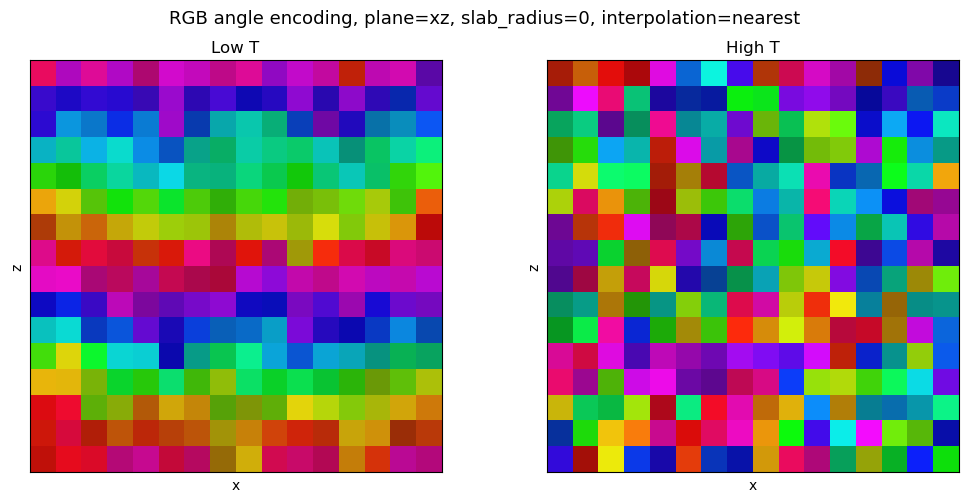

Saved: figures/report/visual_options/02_rgb_bicubic_rendering.png
Saved: figures/report/visual_options/02_rgb_bicubic_rendering.pdf


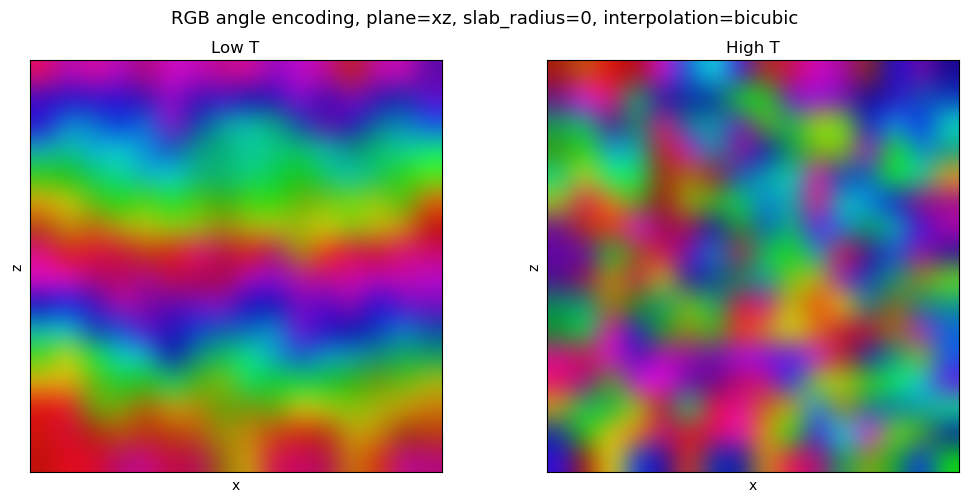

Saved: figures/report/visual_options/03_rgb_bicubic_slab_average_3_slices.png
Saved: figures/report/visual_options/03_rgb_bicubic_slab_average_3_slices.pdf


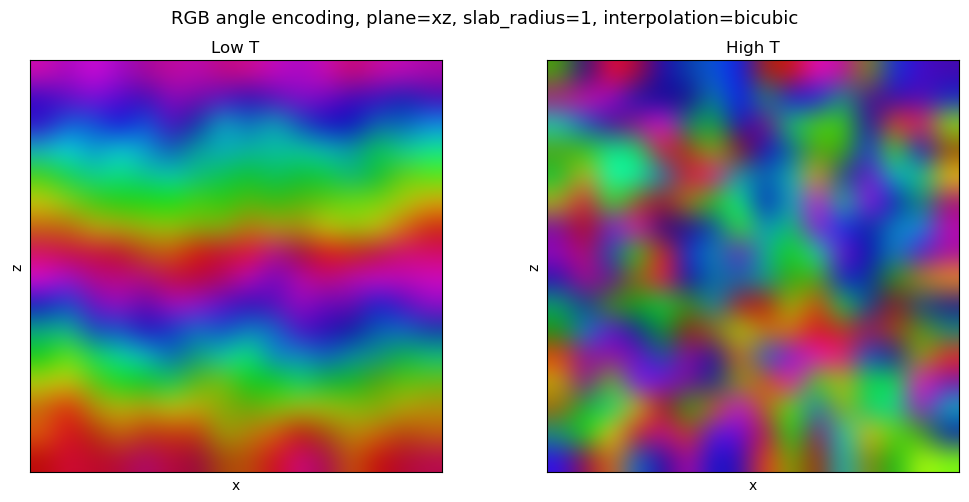

Saved: figures/report/visual_options/04_rgb_slab_average_with_colorwheel.png
Saved: figures/report/visual_options/04_rgb_slab_average_with_colorwheel.pdf


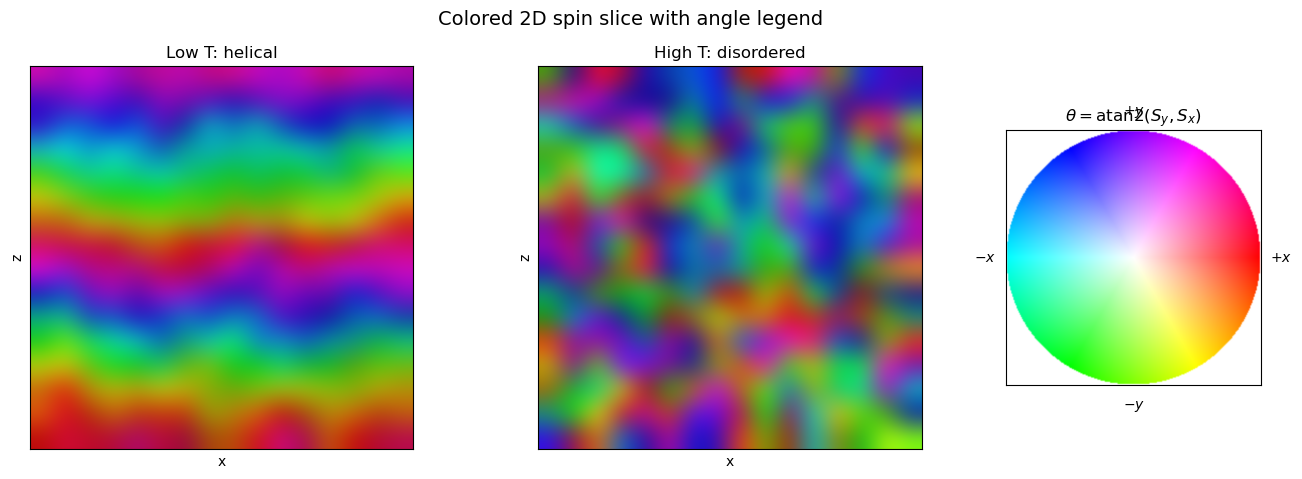

/tmp/ipykernel_7052/3878386453.py:279: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: figures/report/visual_options/05_theta_twilight_nearest.png
Saved: figures/report/visual_options/05_theta_twilight_nearest.pdf


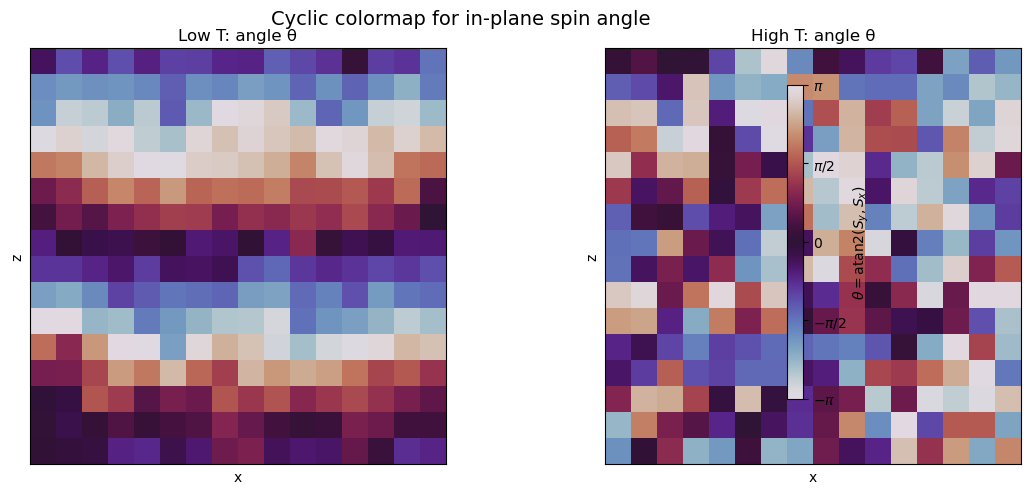

/tmp/ipykernel_7052/3878386453.py:279: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: figures/report/visual_options/06_theta_twilight_slab_bicubic.png
Saved: figures/report/visual_options/06_theta_twilight_slab_bicubic.pdf


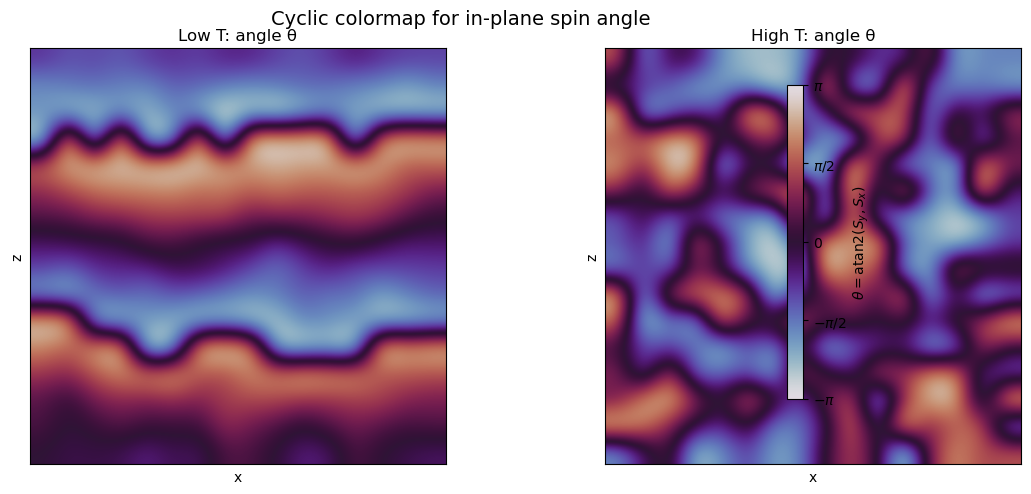

/tmp/ipykernel_7052/3878386453.py:334: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: figures/report/visual_options/07_sz_component.png
Saved: figures/report/visual_options/07_sz_component.pdf


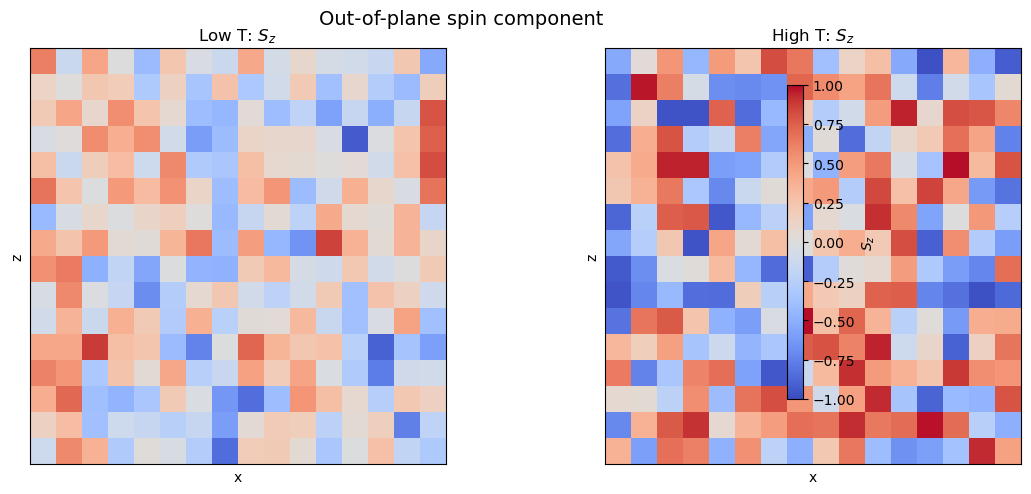

/tmp/ipykernel_7052/3878386453.py:377: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: figures/report/visual_options/08_lowT_components.png
Saved: figures/report/visual_options/08_lowT_components.pdf


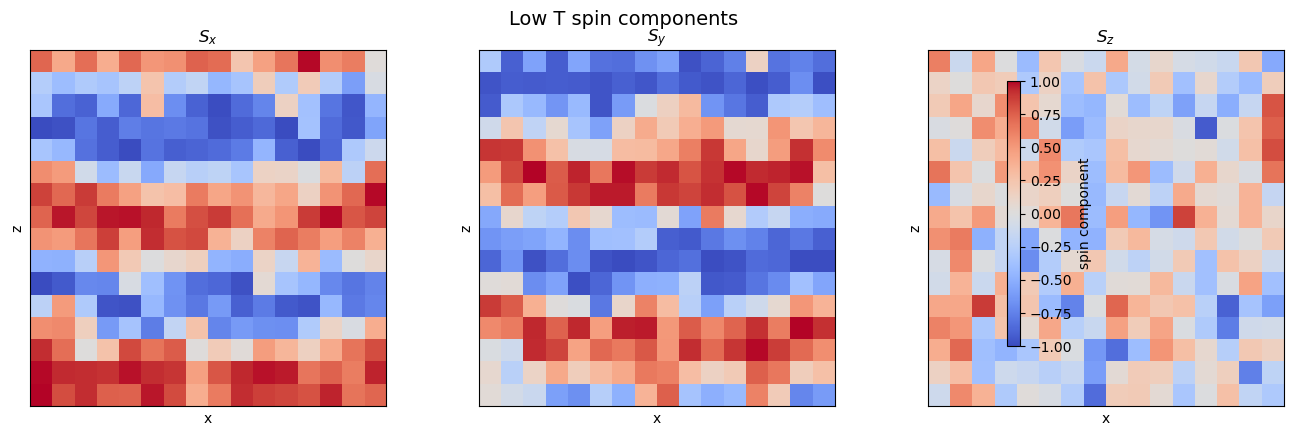

/tmp/ipykernel_7052/3878386453.py:377: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: figures/report/visual_options/09_highT_components.png
Saved: figures/report/visual_options/09_highT_components.pdf


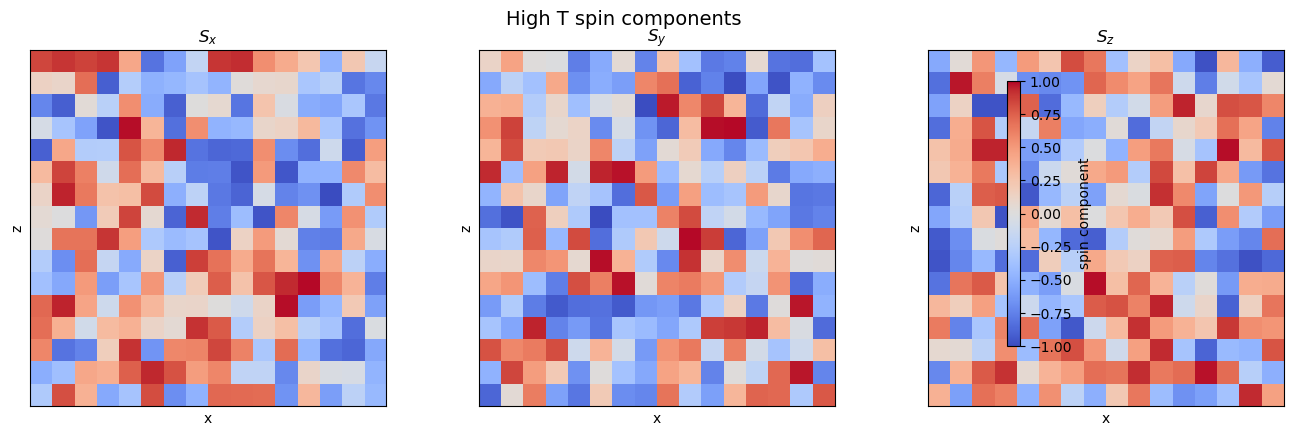

/tmp/ipykernel_7052/3878386453.py:451: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: figures/report/visual_options/10_angle_gradient_disorder_diagnostic.png
Saved: figures/report/visual_options/10_angle_gradient_disorder_diagnostic.pdf


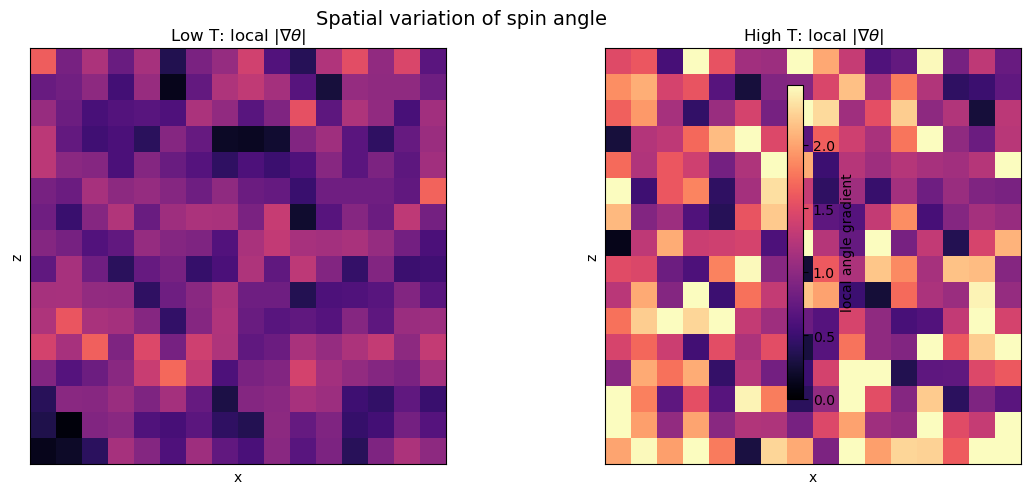


All visualization options were saved in:
/home/iason/projects/CSP26/Computational_Statistical_Physics/Project/notebooks/figures/report/visual_options


In [21]:
# ============================================================
# Visualization options for 2D spin slices
# No arrows: color encodes spin direction / components
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from pathlib import Path

OUTDIR = Path("figures/report/visual_options")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Basic helpers
# ------------------------------------------------------------

def normalize_spins(arr, eps=1e-12):
    """Normalize spin vectors after optional slab averaging."""
    norm = np.linalg.norm(arr, axis=-1, keepdims=True)
    return arr / np.maximum(norm, eps)


def get_spin_slice(spins, plane="xz", index=None, slab_radius=0):
    """
    Extract a 2D slice from a 3D spin configuration.

    spins shape: (L, L, L, 3)
    plane: "xy", "xz", or "yz"
    slab_radius:
        0 -> single slice
        1 -> average over 3 neighboring slices
        2 -> average over 5 neighboring slices
    """
    L = spins.shape[0]
    if index is None:
        index = L // 2

    inds = [(index + k) % L for k in range(-slab_radius, slab_radius + 1)]

    if plane == "xz":
        sl = spins[:, inds, :, :].mean(axis=1)
        xlabel, ylabel = "x", "z"
    elif plane == "xy":
        sl = spins[:, :, inds, :].mean(axis=2)
        xlabel, ylabel = "x", "y"
    elif plane == "yz":
        sl = spins[inds, :, :, :].mean(axis=0)
        xlabel, ylabel = "y", "z"
    else:
        raise ValueError("plane must be 'xy', 'xz', or 'yz'")

    sl = normalize_spins(sl)

    # Put first coordinate on horizontal axis, second on vertical axis.
    sl = np.swapaxes(sl, 0, 1)
    sl = sl[::-1, :, :]

    return sl, xlabel, ylabel


def angle_from_slice(sl):
    """In-plane spin angle theta = atan2(Sy, Sx)."""
    return np.arctan2(sl[..., 1], sl[..., 0])


def rgb_from_spin_slice(sl, use_sz_brightness=True):
    """
    HSV encoding:
        hue        = atan2(Sy, Sx)
        saturation = constant
        value      = optional function of Sz
    """
    theta = angle_from_slice(sl)
    hue = (theta / (2 * np.pi)) % 1.0
    saturation = np.ones_like(hue) * 0.95

    if use_sz_brightness:
        value = 0.55 + 0.45 * (sl[..., 2] + 1.0) / 2.0
    else:
        value = np.ones_like(hue)

    hsv = np.stack([hue, saturation, value], axis=-1)
    return hsv_to_rgb(hsv)


def make_color_wheel(size=240):
    """Color wheel legend for theta = atan2(Sy,Sx)."""
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y)

    R = np.sqrt(X**2 + Y**2)
    theta = np.arctan2(Y, X)

    hue = (theta / (2 * np.pi)) % 1.0
    saturation = np.clip(R, 0, 1)
    value = np.ones_like(hue)

    hsv = np.stack([hue, saturation, value], axis=-1)
    rgb = hsv_to_rgb(hsv)
    rgb[R > 1] = 1.0

    return rgb


def savefig(fig, name):
    png = OUTDIR / f"{name}.png"
    pdf = OUTDIR / f"{name}.pdf"
    fig.savefig(png, dpi=450, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print("Saved:", png)
    print("Saved:", pdf)


# ------------------------------------------------------------
# Option 1/2/3: RGB angle encoding, different rendering choices
# ------------------------------------------------------------

def plot_rgb_pair(
    low_spins,
    high_spins,
    plane="xz",
    index=None,
    slab_radius=0,
    interpolation="nearest",
    use_sz_brightness=True,
    name="rgb_pair",
):
    low_sl, xlabel, ylabel = get_spin_slice(
        low_spins, plane=plane, index=index, slab_radius=slab_radius
    )
    high_sl, _, _ = get_spin_slice(
        high_spins, plane=plane, index=index, slab_radius=slab_radius
    )

    low_img = rgb_from_spin_slice(low_sl, use_sz_brightness=use_sz_brightness)
    high_img = rgb_from_spin_slice(high_sl, use_sz_brightness=use_sz_brightness)

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.0))

    axes[0].imshow(low_img, interpolation=interpolation)
    axes[0].set_title("Low T")
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel(ylabel)

    axes[1].imshow(high_img, interpolation=interpolation)
    axes[1].set_title("High T")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel(ylabel)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(
        rf"RGB angle encoding, plane={plane}, slab_radius={slab_radius}, interpolation={interpolation}",
        fontsize=13,
    )
    fig.tight_layout()
    savefig(fig, name)
    plt.show()


# ------------------------------------------------------------
# Option 4: RGB encoding + color wheel legend
# ------------------------------------------------------------

def plot_rgb_pair_with_wheel(
    low_spins,
    high_spins,
    plane="xz",
    index=None,
    slab_radius=0,
    interpolation="bicubic",
    name="rgb_pair_with_colorwheel",
):
    low_sl, xlabel, ylabel = get_spin_slice(
        low_spins, plane=plane, index=index, slab_radius=slab_radius
    )
    high_sl, _, _ = get_spin_slice(
        high_spins, plane=plane, index=index, slab_radius=slab_radius
    )

    low_img = rgb_from_spin_slice(low_sl, use_sz_brightness=True)
    high_img = rgb_from_spin_slice(high_sl, use_sz_brightness=True)
    wheel = make_color_wheel()

    fig, axes = plt.subplots(
        1, 3,
        figsize=(13.5, 4.8),
        gridspec_kw={"width_ratios": [1, 1, 0.55]},
    )

    axes[0].imshow(low_img, interpolation=interpolation)
    axes[0].set_title("Low T: helical")
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel(ylabel)

    axes[1].imshow(high_img, interpolation=interpolation)
    axes[1].set_title("High T: disordered")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel(ylabel)

    axes[2].imshow(wheel, interpolation="bicubic")
    axes[2].set_title(r"$\theta=\mathrm{atan2}(S_y,S_x)$")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    axes[2].text(wheel.shape[1] + 8, wheel.shape[0] / 2, r"$+x$", va="center")
    axes[2].text(wheel.shape[1] / 2, -10, r"$+y$", ha="center", va="bottom")
    axes[2].text(-10, wheel.shape[0] / 2, r"$-x$", ha="right", va="center")
    axes[2].text(wheel.shape[1] / 2, wheel.shape[0] + 12, r"$-y$", ha="center", va="top")

    fig.suptitle("Colored 2D spin slice with angle legend", fontsize=14)
    fig.tight_layout()
    savefig(fig, name)
    plt.show()


# ------------------------------------------------------------
# Option 5: Cyclic scalar colormap for theta with colorbar
# ------------------------------------------------------------

def plot_angle_colormap_pair(
    low_spins,
    high_spins,
    plane="xz",
    index=None,
    slab_radius=0,
    interpolation="nearest",
    cmap="twilight",
    name="theta_colormap_pair",
):
    low_sl, xlabel, ylabel = get_spin_slice(
        low_spins, plane=plane, index=index, slab_radius=slab_radius
    )
    high_sl, _, _ = get_spin_slice(
        high_spins, plane=plane, index=index, slab_radius=slab_radius
    )

    low_theta = angle_from_slice(low_sl)
    high_theta = angle_from_slice(high_sl)

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

    im0 = axes[0].imshow(
        low_theta,
        cmap=cmap,
        vmin=-np.pi,
        vmax=np.pi,
        interpolation=interpolation,
    )
    axes[0].set_title("Low T: angle θ")

    im1 = axes[1].imshow(
        high_theta,
        cmap=cmap,
        vmin=-np.pi,
        vmax=np.pi,
        interpolation=interpolation,
    )
    axes[1].set_title("High T: angle θ")

    for ax in axes:
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_xticks([])
        ax.set_yticks([])

    cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.85)
    cbar.set_label(r"$\theta=\mathrm{atan2}(S_y,S_x)$")
    cbar.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    cbar.set_ticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])

    fig.suptitle("Cyclic colormap for in-plane spin angle", fontsize=14)
    fig.tight_layout()
    savefig(fig, name)
    plt.show()


# ------------------------------------------------------------
# Option 6: Sz component map
# ------------------------------------------------------------

def plot_sz_pair(
    low_spins,
    high_spins,
    plane="xz",
    index=None,
    slab_radius=0,
    interpolation="nearest",
    name="sz_pair",
):
    low_sl, xlabel, ylabel = get_spin_slice(
        low_spins, plane=plane, index=index, slab_radius=slab_radius
    )
    high_sl, _, _ = get_spin_slice(
        high_spins, plane=plane, index=index, slab_radius=slab_radius
    )

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

    im0 = axes[0].imshow(
        low_sl[..., 2],
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        interpolation=interpolation,
    )
    axes[0].set_title(r"Low T: $S_z$")

    im1 = axes[1].imshow(
        high_sl[..., 2],
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        interpolation=interpolation,
    )
    axes[1].set_title(r"High T: $S_z$")

    for ax in axes:
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_xticks([])
        ax.set_yticks([])

    cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.85)
    cbar.set_label(r"$S_z$")

    fig.suptitle("Out-of-plane spin component", fontsize=14)
    fig.tight_layout()
    savefig(fig, name)
    plt.show()


# ------------------------------------------------------------
# Option 7: Sx, Sy, Sz component panels
# ------------------------------------------------------------

def plot_component_panels(
    spins,
    title,
    plane="xz",
    index=None,
    slab_radius=0,
    interpolation="nearest",
    name="components",
):
    sl, xlabel, ylabel = get_spin_slice(
        spins, plane=plane, index=index, slab_radius=slab_radius
    )

    components = [r"$S_x$", r"$S_y$", r"$S_z$"]
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

    for k, ax in enumerate(axes):
        im = ax.imshow(
            sl[..., k],
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            interpolation=interpolation,
        )
        ax.set_title(components[k])
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_xticks([])
        ax.set_yticks([])

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.82)
    cbar.set_label("spin component")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    savefig(fig, name)
    plt.show()


# ------------------------------------------------------------
# Option 8: Difference / disorder view
# ------------------------------------------------------------

def plot_local_angle_gradient(
    low_spins,
    high_spins,
    plane="xz",
    index=None,
    slab_radius=0,
    interpolation="nearest",
    name="angle_gradient_pair",
):
    """
    Shows spatial variation of angle.
    Low T helix should show smoother structured gradients;
    high T should look noisy.
    """
    low_sl, xlabel, ylabel = get_spin_slice(
        low_spins, plane=plane, index=index, slab_radius=slab_radius
    )
    high_sl, _, _ = get_spin_slice(
        high_spins, plane=plane, index=index, slab_radius=slab_radius
    )

    def grad_mag(sl):
        theta = angle_from_slice(sl)
        # unwrap along both directions for visual gradient
        tx = np.unwrap(theta, axis=1)
        tz = np.unwrap(theta, axis=0)
        gx = np.gradient(tx, axis=1)
        gz = np.gradient(tz, axis=0)
        return np.sqrt(gx**2 + gz**2)

    low_g = grad_mag(low_sl)
    high_g = grad_mag(high_sl)

    vmax = np.percentile(np.concatenate([low_g.ravel(), high_g.ravel()]), 95)

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

    im0 = axes[0].imshow(
        low_g,
        cmap="magma",
        vmin=0,
        vmax=vmax,
        interpolation=interpolation,
    )
    axes[0].set_title(r"Low T: local $|\nabla\theta|$")

    im1 = axes[1].imshow(
        high_g,
        cmap="magma",
        vmin=0,
        vmax=vmax,
        interpolation=interpolation,
    )
    axes[1].set_title(r"High T: local $|\nabla\theta|$")

    for ax in axes:
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_xticks([])
        ax.set_yticks([])

    cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.85)
    cbar.set_label(r"local angle gradient")

    fig.suptitle("Spatial variation of spin angle", fontsize=14)
    fig.tight_layout()
    savefig(fig, name)
    plt.show()


# ============================================================
# Generate all options
# Change low_spins/high_spins here if your variable names differ.
# ============================================================

# Option A: exact pixels, no smoothing
plot_rgb_pair(
    low_spins,
    high_spins,
    interpolation="nearest",
    slab_radius=0,
    name="01_rgb_exact_pixels_no_smoothing",
)

# Option B: smoother rendering only
plot_rgb_pair(
    low_spins,
    high_spins,
    interpolation="bicubic",
    slab_radius=0,
    name="02_rgb_bicubic_rendering",
)

# Option C: slight physical/visual smoothing by averaging 3 neighboring slices
plot_rgb_pair(
    low_spins,
    high_spins,
    interpolation="bicubic",
    slab_radius=1,
    name="03_rgb_bicubic_slab_average_3_slices",
)

# Option D: best report-style candidate with color wheel legend
plot_rgb_pair_with_wheel(
    low_spins,
    high_spins,
    interpolation="bicubic",
    slab_radius=1,
    name="04_rgb_slab_average_with_colorwheel",
)

# Option E: cyclic scalar angle map with colorbar
plot_angle_colormap_pair(
    low_spins,
    high_spins,
    interpolation="nearest",
    slab_radius=0,
    cmap="twilight",
    name="05_theta_twilight_nearest",
)

# Option F: smoother cyclic angle map
plot_angle_colormap_pair(
    low_spins,
    high_spins,
    interpolation="bicubic",
    slab_radius=1,
    cmap="twilight",
    name="06_theta_twilight_slab_bicubic",
)

# Option G: show out-of-plane component Sz
plot_sz_pair(
    low_spins,
    high_spins,
    interpolation="nearest",
    slab_radius=0,
    name="07_sz_component",
)

# Option H: low-T spin components
plot_component_panels(
    low_spins,
    title="Low T spin components",
    interpolation="nearest",
    slab_radius=0,
    name="08_lowT_components",
)

# Option I: high-T spin components
plot_component_panels(
    high_spins,
    title="High T spin components",
    interpolation="nearest",
    slab_radius=0,
    name="09_highT_components",
)

# Option J: angle-gradient / disorder diagnostic
plot_local_angle_gradient(
    low_spins,
    high_spins,
    interpolation="nearest",
    slab_radius=0,
    name="10_angle_gradient_disorder_diagnostic",
)

print("\nAll visualization options were saved in:")
print(OUTDIR.resolve())


## Optional: load Euler/C++ saved configuration

If the C++ code saved a CSV configuration with `--save-config`, you can load it and produce the same colored slice here.


In [18]:

def load_cpp_config_csv(path):
    cfg = pd.read_csv(path)
    L = int(cfg[["x", "y", "z"]].to_numpy().max()) + 1
    spins = np.zeros((L, L, L, 3), dtype=np.float64)
    for row in cfg.itertuples(index=False):
        spins[int(row.x), int(row.y), int(row.z)] = [row.Sx, row.Sy, row.Sz]
    return spins

# Example:
# spins_cpp = load_cpp_config_csv("../results/configs/config_L16_T0p800_J1p000_D1p000_seed1.csv")
# plot_colored_slice(spins_cpp, "C++ saved config colored slice", "cpp_colored_slice.png", plane="xz")



## Optional: Python-side ML sanity check from local scan features

This is not the final ML result. The final ML uses Euler configurations and the 3D CNN in `ml/train_cnn3d.py`.

Here we just demonstrate that Python can make a simple feature-based \(P_{\mathrm{helical}}(T)\) curve.


In [19]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


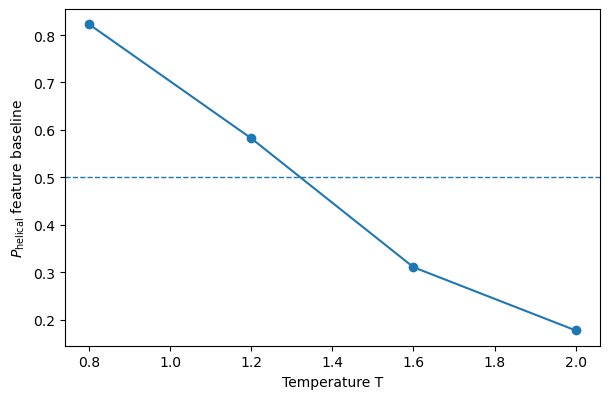

In [20]:

# Simple logistic regression using helical order and energy as features, if scikit-learn is installed.
try:
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression

    feat_df = df[(df["T"] <= 0.9) | (df["T"] >= 1.8)].copy()
    feat_df["label"] = (feat_df["T"] <= 0.9).astype(int)

    X_train = feat_df[["E_density_mean", "helical_order_mean", "q_peak_final"]].to_numpy()
    y_train = feat_df["label"].to_numpy()

    clf = make_pipeline(StandardScaler(), LogisticRegression())
    clf.fit(X_train, y_train)

    X_all = df[["E_density_mean", "helical_order_mean", "q_peak_final"]].to_numpy()
    df["P_helical_feature"] = clf.predict_proba(X_all)[:, list(clf.classes_).index(1)]

    g = df.groupby("T")["P_helical_feature"].mean().reset_index()
    fig, ax = plt.subplots(figsize=(6.2, 4.1))
    ax.plot(g["T"], g["P_helical_feature"], marker="o")
    ax.axhline(0.5, linestyle="--", linewidth=1)
    ax.set_xlabel("Temperature T")
    ax.set_ylabel(r"$P_{\mathrm{helical}}$ feature baseline")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "python_feature_baseline_P_helical.png", dpi=200)
    fig.savefig(FIG_DIR / "python_feature_baseline_P_helical.pdf")
    plt.show()

except Exception as e:
    print("Skipping feature baseline because scikit-learn is unavailable or data is insufficient.")
    print("Error:", e)
